In [2]:
%%capture
%run script_nettoyage.ipynb

Analyse 1 : Evolution des fréquentations des musées par type de musées.

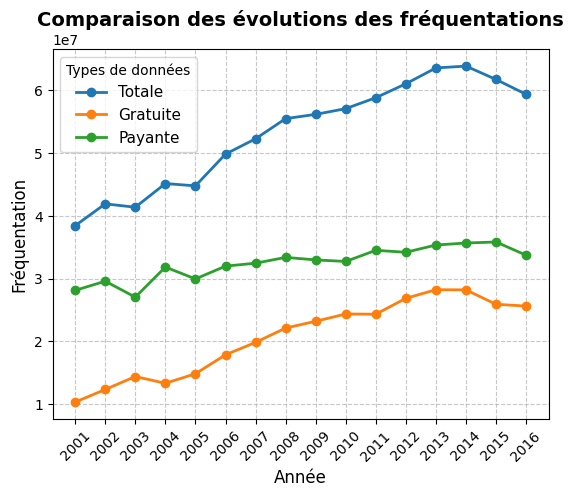

In [3]:
from fonctions import tracer_comparaison_frequentation 

mes_donnees = {
    "Totale": df_freq_totale,
    "Gratuite": df_freq_gratuite,
    "Payante": df_freq_payante    
}

tracer_comparaison_frequentation(
    mes_donnees, 
    an='annee',           
    freq='freq_net'    
)

Nous souhaitons à présent représenter sur une carte de la France métropolitaine la fréquentation des musées par région. Cependant, nous voulons également représenter la fréquentation par rapport au nombre d'habitants de le région. Pour cela nous utilisons une table présentant le nombre d'habitants par région en 2010 (fichier data.py). Nous faisons ensuite une jointure de cette table avec notre table fréquentation_totale. Le fait de prendre comme 2010 comme référence pour toutes les années de notre base de données n'est pas précis; l'objectif n'est pas d'être précis mais de montrer les tendances. Nous créons la colonne freq_pour_1000_hab représentant la fréquentation du musée, une année donnée pour 1 000 habitants.

In [4]:
from data import pop_2010

df_freq_totale = df_freq_totale.merge(pop_2010, on="NOMREG", how="left")

df_freq_totale["freq_pour_1000_hab"] = (
    pd.to_numeric(df_freq_totale["freq_net"], errors="coerce")
    / df_freq_totale["population_2010"] * 1000
)

df_freq_totale

,REF DU MUSEE,NOMREG,NOM DU MUSEE,VILLE,Fréquentation,annee,frequentation,speciale,freq_net,Statut,population_2010,freq_pour_1000_hab
0,0105301,AUVERGNE-RHÔNE-ALPES,Musée du Brou,BOURG-EN-BRESSE,Totale,2001,74056,False,74056.0,Ouvert,7578078,9.772399
1,0105302,AUVERGNE-RHÔNE-ALPES,Musée Départemental des Pays De l'Ain,BOURG-EN-BRESSE,Totale,2001,NaN,True,NaN,NA,7578078,NaN
2,0106401,AUVERGNE-RHÔNE-ALPES,Musée de la Société d'Histoire et d'Archéologie,BRIORD,Totale,2001,100,False,100.0,Ouvert,7578078,0.013196
3,0113701,AUVERGNE-RHÔNE-ALPES,Musée Départemental du Revermont,TREFFORT-CUISIAT,Totale,2001,22234,False,22234.0,Ouvert,7578078,2.933989
4,0119201,AUVERGNE-RHÔNE-ALPES,Musée Archéologique,IZERNORE,Totale,2001,204,False,204.0,Ouvert,7578078,0.026920
...,...,...,...,...,...,...,...,...,...,...,...,...
19851,8413701,PROVENCE-ALPES-CÔTE D'AZUR,Musée Archéologique Théo Desplans,VAISON-LA-ROMAINE,Totale,2016,76154,False,76154.0,Ouvert,4899155,15.544313
19852,8413801,PROVENCE-ALPES-CÔTE D'AZUR,Musée Départemental du Cartonnage et de l'Impr...,VALREAS,Totale,2016,NC,True,NaN,NA,4899155,NaN
19853,8413901,PROVENCE-ALPES-CÔTE D'AZUR,Musée-Bibliothèque François Pétrarque,FONTAINE-DE-VAUCLUSE,Totale,2016,2118,False,2118.0,Ouvert,4899155,0.432319
19854,8413902,PROVENCE-ALPES-CÔTE D'AZUR,Musée Jean Garcin 39-45 : L'appel de la Liberté,FONTAINE-DE-VAUCLUSE,Totale,2016,7718,False,7718.0,Ouvert,4899155,1.575374


La fonction carto_frequentation_region permet de représenter sur une carte de la France métropolitaine la fréquentation par région une année donnée par quartiles. L'argument col_freq permet de choisir entre représenter la fréquentation ou la fréquentation pour 1 000 habitants.

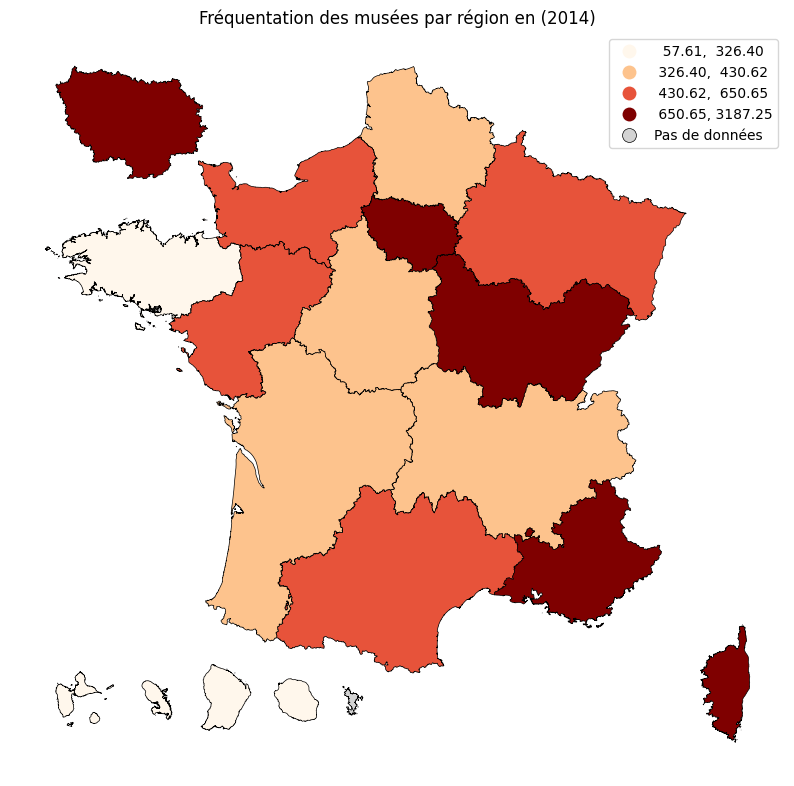

In [6]:
from fonctions import carto_frequentation_region

carte_2022 = carto_frequentation_region(df_freq_totale, "2014", col_freq="freq_pour_1000_hab")

Au moins une région dépasse les 1 000 visiteurs pour 1 000 habitants. Qui dépasse ce seuil et en quelles années ?

In [7]:
freq_region_annee = (
    df_freq_totale
    .groupby(["annee", "NOMREG"], as_index=False)["freq_pour_1000_hab"]
    .sum()
)

freq_region_annee.loc[
    freq_region_annee["freq_pour_1000_hab"] > 1000,
    ["annee", "NOMREG", "freq_pour_1000_hab"]
].sort_values(["NOMREG", "annee"])

,annee,NOMREG,freq_pour_1000_hab
17,2001,ÎLE-DE-France,1672.452286
35,2002,ÎLE-DE-France,1808.144484
53,2003,ÎLE-DE-France,1805.578949
71,2004,ÎLE-DE-France,2028.775180
89,2005,ÎLE-DE-France,2117.515654
107,2006,ÎLE-DE-France,2517.444419
125,2007,ÎLE-DE-France,2635.561368
143,2008,ÎLE-DE-France,2805.628838
161,2009,ÎLE-DE-France,2814.197818
179,2010,ÎLE-DE-France,2838.559289


La région Ile-De-France dépasse ce seuil tous les ans. Cela s'explique par le tourisme très important que connaît cette région.